# Прогнозирование прогрессии заболевания после радиохирургии

## Постановка задачи

Задача — предсказать вероятность прогрессии заболевания у пациентов
после радиохирургического лечения (Gamma Knife) и определить, какие
клинические факторы влияют на исход сильнее всего.

**Тип задачи:** бинарная классификация.

**Метрика:** balanced accuracy (метрика соревнования на kaggle)

## Блок №1

## Первичный осмотр и мелкие изменения

### Загрузка и просмотр исходных данных

In [68]:
import pandas as pd
import numpy as np

RANDOM_STATE = 42
RAW_TARGET = 'Интракраниальная прогрессия'

df = pd.read_csv('train.csv')
print(f'Размер: {df.shape[0]} строк, {df.shape[1]} столбцов')
print(f'Полных дубликатов: {df.duplicated().sum()}')

Размер: 872 строк, 20 столбцов
Полных дубликатов: 0


In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

BASE_RATE = 0.654   # базовая доля прогрессии — опорная линия на графиках

In [70]:
df

,Пол,Дата рождения,Онкологический диагноз,Дата постановки онкологического диагноза / начала первичного лечения,Дата удаления первичного очага,Дата развития МГМ,Активирующие мутации,Дата проведения ОВГМ,Дата операции на ГМ,Число РХ процедур на ГН,Дата 1-ой РХ,Индекс Карновского,Число очагов в ГМ,Суммарный объем очагов,Объем максимального очага,Экстракраниальные метастазы,Лекарственное лечение,Локальный рецидив,Дистантные метастазы,Интракраниальная прогрессия
0,М,04.06.1947,НМРЛ,01.04.2008,NaN,01.05.2009,NaN,нет,NaN,1,10.11.2009,70,1,"6,20","6,20",NaN,Химиотерапия,нет,нет,нет
1,М,13.03.1951,РП,01.12.1992,NaN,01.05.2008,NaN,NaN,01.05.2008,3,21.03.2013,70,1,"0,36","0,36",NaN,Таргетная терапия,10.04.2014,10.04.2014,ЛР+ДМ
2,М,21.06.1957,Меланома,01.02.2008,01.02.2008,01.06.2009,NaN,нет,нет,1,08.10.2009,80,3,"0,42","0,37",есть,Химиотерапия,нет,#REF!,ДМ
3,М,24.02.1959,НМРЛ,01.12.2013,не удален,30.05.2014,NaN,NaN,NaN,1,14.07.2014,60,4,"6,39","5,47",есть,Химиотерапия,нет,нет,нет
4,Ж,19.12.1961,КРР,29.12.2010,29.12.2010,01.09.2013,NaN,NaN,01.09.2013,1,26.02.2015,80,3,"5,50","4,62",есть,Таргетная терапия,нет,нет,нет
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
867,М,31.07.1980,Меланома,01.01.2010,01.01.2010,01.03.2010,NaN,нет,нет,1,01.04.2010,70,12,"9,58","4,20",есть,NaN,нет,нет,нет
868,Ж,31.08.1945,НМРЛ,NaN,NaN,NaN,есть,18.04.2012,нет,1,10.04.2012,80,14,"18,82","7,68",есть,Таргетная терапия,нет,нет,нет
869,Ж,31.08.1953,РП,01.07.2007,01.07.2007,01.12.2008,NaN,нет,нет,1,11.01.2009,70,4,"2,46","1,90",есть,Таргетная терапия,нет,нет,нет
870,Ж,31.12.1946,РМЖ,01.12.2004,NaN,01.11.2006,нет,01.12.2006,01.12.2006,1,08.02.2008,80,8,"9,69","4,80",есть,Химиотерапия,нет,нет,нет


### Конструирование таргета

In [71]:
print(df[RAW_TARGET].value_counts(dropna=False))

# ЛР — локальный рецидив, ДМ — дистантные метастазы.
# Для бинарной задачи любое зафиксированное событие = прогрессия.
mask_labeled = df[RAW_TARGET].notna()
df_labeled = df[mask_labeled].copy()
df_labeled['target'] = (df_labeled[RAW_TARGET] != 'нет').astype(int)

print(f'\nРазмечено: {mask_labeled.sum()} из {len(df)} '
      f'({mask_labeled.mean():.1%})')
print(df_labeled['target'].value_counts(normalize=True).round(3))

Интракраниальная прогрессия
ДМ       279
нет      235
NaN      192
ЛР+ДМ     99
ЛР        67
Name: count, dtype: int64

Размечено: 680 из 872 (78.0%)
target
1    0.654
0    0.346
Name: proportion, dtype: float64


**Решение по пропущенному таргету.** У 192 пациентов (22%) исход неизвестен.
Заполнять таргет нельзя — это не признак: любая импутация здесь означала бы
выдумывание ответов и обучение модели на собственных предположениях.
Эти строки исключаются из обучающей выборки.

### Аудит утечек

In [72]:
def event_occurred(value):
    """Колонки содержат либо дату события, либо 'нет', либо мусор Excel."""
    if pd.isna(value):
        return np.nan
    value = str(value).strip()
    if value == 'нет':
        return 0
    if value.startswith('#'):      # #REF! и прочие артефакты Excel
        return np.nan
    return 1

lr = df_labeled['Локальный рецидив'].apply(event_occurred)
dm = df_labeled['Дистантные метастазы'].apply(event_occurred)

# Восстанавливаем таргет напрямую из двух колонок
reconstructed = np.where((lr == 1) | (dm == 1), 1, 0)
valid = lr.notna() & dm.notna()

agreement = (reconstructed[valid] == df_labeled.loc[valid, 'target']).mean()
print(f'Таргет восстанавливается из ЛР/ДМ в {agreement:.1%} случаев '
      f'(n={valid.sum()})')

Таргет восстанавливается из ЛР/ДМ в 97.6% случаев (n=670)


**Результат: 97.6%.** Признаки `Локальный рецидив` и `Дистантные метастазы` —
это даты наступления тех самых событий, из которых определён таргет.
Это не корреляция, а тождество: таргет записан в другом виде.

Оставшиеся 2.4% расхождений — ошибки ручного ввода, косвенно
подтверждающие, что данные заполнялись вручную.

Обе колонки удаляются безусловно.

In [73]:
# Третий признак-утечка: число РХ процедур
ct = pd.crosstab(df_labeled['Число РХ процедур на ГН'], df_labeled['target'],
                 margins=True)
ct['P(прогрессия)'] = (ct[1] / ct['All']).round(3)
print(ct)

target                     0    1  All  P(прогрессия)
Число РХ процедур на ГН                              
1                        228  218  446          0.489
2                          7  159  166          0.958
3                          0   47   47          1.000
4                          0   16   16          1.000
5                          0    3    3          1.000
6                          0    2    2          1.000
All                      235  445  680          0.654


При одной процедуре прогрессия у 48.9% пациентов, при двух и более —
у 95.8–100%. Механизм тот же: повторную радиохирургию назначают
*вследствие* прогрессии. На момент прогноза (сразу после первой РХ)
это значение ещё не существует — признак не проходит тест времени
предсказания и удаляется.

*Оговорка:* часть повторных процедур может быть плановой многоэтапной
радиохирургией, однако отличить её по имеющимся данным невозможно.

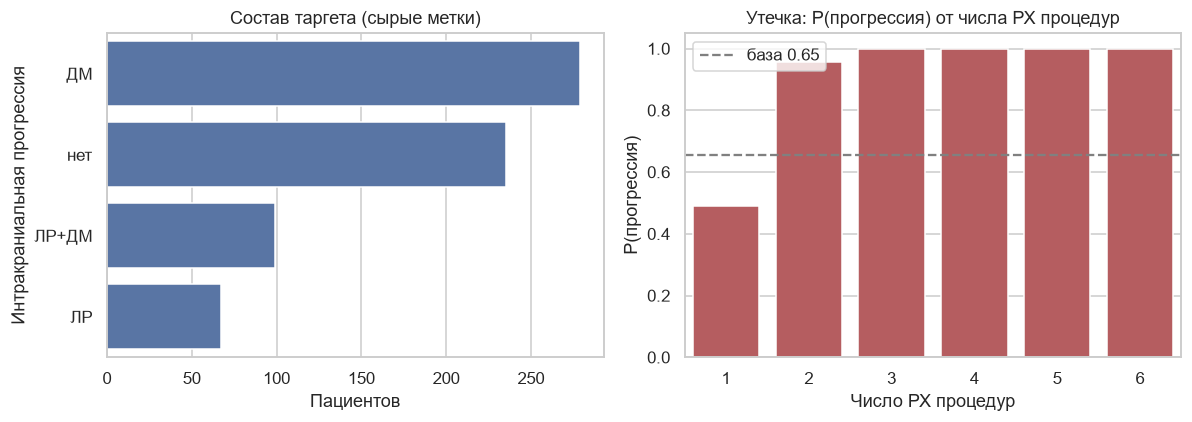

In [75]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

target_counts = df[RAW_TARGET].value_counts()
sns.barplot(x=target_counts.values, y=target_counts.index, ax=ax[0], color='#4C72B0')
ax[0].set(title='Состав таргета (сырые метки)', xlabel='Пациентов')

leak_rate = df_labeled.groupby('Число РХ процедур на ГН')['target'].mean()
sns.barplot(x=leak_rate.index, y=leak_rate.values, ax=ax[1], color='#C44E52')
ax[1].axhline(BASE_RATE, ls='--', color='gray', label=f'база {BASE_RATE:.2f}')
ax[1].set(title='Утечка: P(прогрессия) от числа РХ процедур',
          xlabel='Число РХ процедур', ylabel='P(прогрессия)')
ax[1].legend()

plt.tight_layout()
plt.show()

### Демонстрация проблем качества

In [76]:
LEAKY_FEATURES = ['Локальный рецидив', 'Дистантные метастазы',
                  'Число РХ процедур на ГН']

def audit_data_quality(data):
    """Инвентаризация проблем: пропуски, артефакты Excel, смешанные типы."""
    report = []
    for col in data.columns:
        as_str = data[col].astype(str)
        report.append({
            'признак': col,
            'пропуски_%': round(data[col].isna().mean() * 100, 1),
            'артефакты_Excel': as_str.str.startswith('#').sum(),
            'уник_значений': data[col].nunique(),
        })
    return pd.DataFrame(report).sort_values('пропуски_%', ascending=False)

audit_data_quality(df_labeled.drop(columns=LEAKY_FEATURES))

,признак,пропуски_%,артефакты_Excel,уник_значений
6,Активирующие мутации,60.3,0,2
4,Дата удаления первичного очага,38.4,0,198
14,Экстракраниальные метастазы,36.0,0,2
15,Лекарственное лечение,30.9,0,3
7,Дата проведения ОВГМ,11.3,0,91
5,Дата развития МГМ,9.9,0,347
3,Дата постановки онкологического диагноза / нач...,9.0,0,283
8,Дата операции на ГМ,5.3,0,170
1,Дата рождения,0.0,0,664
0,Пол,0.0,0,4


## Блок №2

## Очистка данных

Данные вводились вручную в Excel, поэтому проблемы разнородны:
битые формулы, несогласованный регистр, десятичная запятая,
смешение типов в одной колонке и нарушения хронологии.
Разберём их по категориям.

In [77]:
RAW_TARGET = 'Интракраниальная прогрессия'
DATE_FORMAT = '%d.%m.%Y'

df = pd.read_csv('train.csv')
df = df[df[RAW_TARGET].notna()].copy()
df['target'] = (df[RAW_TARGET] != 'нет').astype(int)

# Артефакты Excel (#REF!, #N/A, #VALUE!) — это отсутствие данных, не значение.
# Ловим по префиксу '#', чтобы правило работало и на новых данных.
excel_artifacts = df.astype(str).apply(lambda col: col.str.startswith('#'))
print(f'Артефактов Excel заменено на NaN: {excel_artifacts.sum().sum()}')
df = df.mask(excel_artifacts)

Артефактов Excel заменено на NaN: 9


In [78]:
def to_date(series):
    """Даты в формате ДД.ММ.ГГГГ; текстовые маркеры ('нет', 'не удален') -> NaT."""
    return pd.to_datetime(series, format=DATE_FORMAT, errors='coerce')

def to_float(series):
    """Числа записаны с десятичной запятой и хранятся как строки."""
    return pd.to_numeric(series.astype(str).str.replace(',', '.', regex=False),
                         errors='coerce')

date_of_rh = to_date(df['Дата 1-ой РХ'])

### Разрезание по времени прогноза

Колонки `Дата проведения ОВГМ` и `Дата операции на ГМ` смешивают
события до и после радиохирургии. Проверим их на утечку.

In [79]:
for col in ['Дата проведения ОВГМ', 'Дата операции на ГМ']:
    dates = to_date(df[col])
    after_rh = dates.notna() & (dates > date_of_rh)
    print(f'{col}:')
    print(f'  после первой РХ: {after_rh.sum()} из {dates.notna().sum()} дат')
    print(f'  P(прогрессия | событие после РХ) = {df.loc[after_rh, "target"].mean():.3f}')
    print(f'  P(прогрессия) в целом            = {df["target"].mean():.3f}\n')

Дата проведения ОВГМ:
  после первой РХ: 57 из 94 дат
  P(прогрессия | событие после РХ) = 0.772
  P(прогрессия) в целом            = 0.654

Дата операции на ГМ:
  после первой РХ: 21 из 176 дат
  P(прогрессия | событие после РХ) = 0.762
  P(прогрессия) в целом            = 0.654



**Результат.** 60% дат ОВГМ приходятся на период *после* радиохирургии,
и в этой подгруппе прогрессия наблюдается у 77% против 65% в среднем.
Объяснение клиническое: облучение всего головного мозга после
радиохирургии — это терапия спасения, назначаемая **при прогрессии**.
Событие является следствием исхода.

**Решение — не удалять колонки, а разрезать их по времени прогноза.**
Сохраняем только факт события *до* первой РХ: предшествующее лечение
известно на момент прогноза и клинически значимо, а всё последующее
отбрасывается как утечка.

In [80]:
clean = pd.DataFrame(index=df.index)
clean['target'] = df['target']

# Признаки-события: строго до момента прогноза
for feature_name, col in [('овгм_до_рх', 'Дата проведения ОВГМ'),
                          ('операция_до_рх', 'Дата операции на ГМ'),
                          ('первичный_очаг_удален', 'Дата удаления первичного очага')]:
    dates = to_date(df[col])
    clean[feature_name] = (dates.notna() & (dates <= date_of_rh)).astype(int)

# Регистр: 'М'/'м' и 'Ж'/'ж' — одни и те же категории
clean['пол_муж'] = (df['Пол'].str.strip().str.upper() == 'М').astype(int)

clean['объем_суммарный'] = to_float(df['Суммарный объем очагов'])
clean['объем_максимальный'] = to_float(df['Объем максимального очага'])
clean['число_очагов'] = df['Число очагов в ГМ']
clean['индекс_карновского'] = df['Индекс Карновского']
clean['диагноз'] = df['Онкологический диагноз'].str.strip()

# Пропуск как самостоятельная категория: непроведённое исследование информативно
clean['мутации'] = df['Активирующие мутации'].fillna('не исследовалось')
clean['лекарственное_лечение'] = df['Лекарственное лечение'].fillna('не указано')
clean['экстракраниальные_мтс'] = df['Экстракраниальные метастазы'].fillna('не указано')

In [81]:
# Интервалы между событиями, а не сами даты
date_of_birth = to_date(df['Дата рождения'])
date_of_mgm = to_date(df['Дата развития МГМ'])
date_of_diagnosis = to_date(
    df['Дата постановки онкологического диагноза / начала первичного лечения'])

clean['возраст_на_рх'] = ((date_of_rh - date_of_birth).dt.days / 365.25).round(1)
clean['дней_диагноз_мгм'] = (date_of_mgm - date_of_diagnosis).dt.days  # скорость метастазирования
clean['дней_мгм_рх'] = (date_of_rh - date_of_mgm).dt.days              # задержка лечения

In [82]:
# Логически невозможные значения обнуляем точечно, не удаляя пациента целиком
impossible = {
    'дней_диагноз_мгм': clean['дней_диагноз_мгм'] < 0,      # МГМ раньше диагноза
    'дней_мгм_рх': clean['дней_мгм_рх'] < 0,                # лечение раньше болезни
}
for col, mask in impossible.items():
    print(f'{col}: {mask.sum()} невозможных значений -> NaN')
    clean.loc[mask, col] = np.nan

# Максимальный очаг не может превышать суммарный объём
volume_error = clean['объем_максимальный'] > clean['объем_суммарный']
print(f'объёмы: {volume_error.sum()} противоречий -> NaN')
clean.loc[volume_error, ['объем_суммарный', 'объем_максимальный']] = np.nan

дней_диагноз_мгм: 9 невозможных значений -> NaN
дней_мгм_рх: 8 невозможных значений -> NaN
объёмы: 3 противоречий -> NaN


**Итог очистки:** 680 наблюдений, 15 признаков, баланс классов 65/35.

Пропуски обработаны двумя разными стратегиями:

- **Категориальные признаки** (`мутации`, `лекарственное_лечение`,
  `экстракраниальные_мтс`) — пропуск переведён в явную категорию
  (`не исследовалось` / `не указано`). Так, 410 пропусков в
  `Активирующие мутации` (60%) стали полноценной категорией:
  сам факт непроведения анализа несёт информацию.
- **Числовые признаки** — пропуск оставлен как `NaN`
  (`дней_диагноз_мгм` — 14.4%, `дней_мгм_рх` — 11.2%, объёмы — 0.4%).
  Импутация выполняется внутри пайплайна на этапе моделирования,
  чтобы статистики считались только по обучающим фолдам.

## Блок №3

## Исследовательский анализ

Анализ строится от клинических гипотез, а не от перебора колонок:
для каждого признака сформулировано ожидание, которое мы проверяем.
Расхождение с ожиданием — не ошибка, а находка, требующая объяснения.

**Проверяемые гипотезы:**
- H1: низкий индекс Карновского → выше вероятность прогрессии
- H2: больше очагов и больший объём → выше вероятность прогрессии
- H3: диагноз влияет на исход (меланома агрессивнее)
- H4: быстрое метастазирование → агрессивная опухоль → выше риск
- H5: факт непроведения анализа на мутации информативен

In [83]:
from scipy.stats import mannwhitneyu, chi2_contingency

def compare_categorical(data, feature, target='target'):
    """Доля прогрессии по категориям + тест независимости хи-квадрат."""
    table = pd.crosstab(data[feature], data[target])
    _, p_value, _, _ = chi2_contingency(table)
    table['n'] = table.sum(axis=1)
    table['P(прогрессия)'] = (table[1] / table['n']).round(3)
    return table.sort_values('P(прогрессия)', ascending=False), p_value

def compare_numeric(data, feature, target='target'):
    """Сравнение распределений по классам (непараметрический тест:
    признаки сильно скошены, нормальность не предполагаем)."""
    no_prog = data.loc[data[target] == 0, feature].dropna()
    prog = data.loc[data[target] == 1, feature].dropna()
    _, p_value = mannwhitneyu(no_prog, prog)
    return no_prog.median(), prog.median(), p_value

In [84]:
# H5: информативен ли факт непроведения анализа?
table, p_value = compare_categorical(clean, 'мутации')
print(table)
print(f'p-value = {p_value:.3f}')

target              0    1    n  P(прогрессия)
мутации                                       
есть               45   95  140          0.679
не исследовалось  143  267  410          0.651
нет                47   83  130          0.638
p-value = 0.769


**H5 отвергнута.** Доля прогрессии практически одинакова во всех трёх
группах (0.68 / 0.65 / 0.64), p = 0.77. Предположение, что сам факт
непроведения молекулярного анализа несёт прогностическую информацию,
данными не подтверждается.

Кодирование пропуска отдельной категорией остаётся корректным решением
(оно не искажает данные), но извлечь из него сигнал не удалось.

In [85]:
# H1: индекс Карновского
karnofsky_groups = pd.cut(clean['индекс_карновского'],
                          bins=[0, 60, 70, 80, 90, 100],
                          labels=['≤60', '70', '80', '90', '100'])
table, p_value = compare_categorical(clean.assign(карновский=karnofsky_groups), 'карновский')
print(table.sort_index())
print(f'p-value = {p_value:.4f}')

target       0    1    n  P(прогрессия)
карновский                             
≤60         12   23   35          0.657
70          81  103  184          0.560
80          94  178  272          0.654
90          46  132  178          0.742
100          2    9   11          0.818
p-value = 0.0057


### H1 отвергнута — и это главная находка анализа

Зависимость оказалась **обратной** ожидаемой: чем **лучше** общее
состояние пациента, тем **чаще** фиксируется прогрессия
(0.56 при индексе 70 → 0.74 при 90 → 0.82 при 100).

**Объяснение: конкурирующие риски и информативное цензурирование.**
Пациент с низким индексом Карновского с высокой вероятностью погибает
от системного прогрессирования заболевания раньше, чем внутричерепная
прогрессия успевает проявиться и быть зафиксированной. В данных он
получает метку «нет прогрессии» — но не потому, что лечение оказалось
эффективным, а потому, что событие не успело наступить.

Иными словами, класс `0` объединяет две принципиально разные группы:
- пациенты, у которых прогрессии действительно не было;
- пациенты, у которых её **не успели наблюдать**.


In [86]:
# Мультиколлинеарность
numeric_features = clean.select_dtypes(include=[np.number]).columns.drop('target')
correlations = clean[numeric_features].corr(method='spearman')

strong = (correlations.abs() > 0.8) & (correlations.abs() < 1.0)
print('Сильно скоррелированные пары:')
for i, j in zip(*np.where(np.triu(strong, k=1))):
    print(f'  {numeric_features[i]} ↔ {numeric_features[j]}: '
          f'{correlations.iloc[i, j]:.2f}')

Сильно скоррелированные пары:
  объем_суммарный ↔ объем_максимальный: 0.93


`объем_суммарный` и `объем_максимальный` скоррелированы на уровне 0.93.
Для линейной модели это разрушает интерпретацию коэффициентов: эффект
распределяется между двумя признаками произвольным образом, вплоть до
смены знака. Оставляем `объем_суммарный` как отражающий общую
опухолевую нагрузку. Для моделей на деревьях мультиколлинеарность
некритична, но признак убираем из общего набора ради сопоставимости.

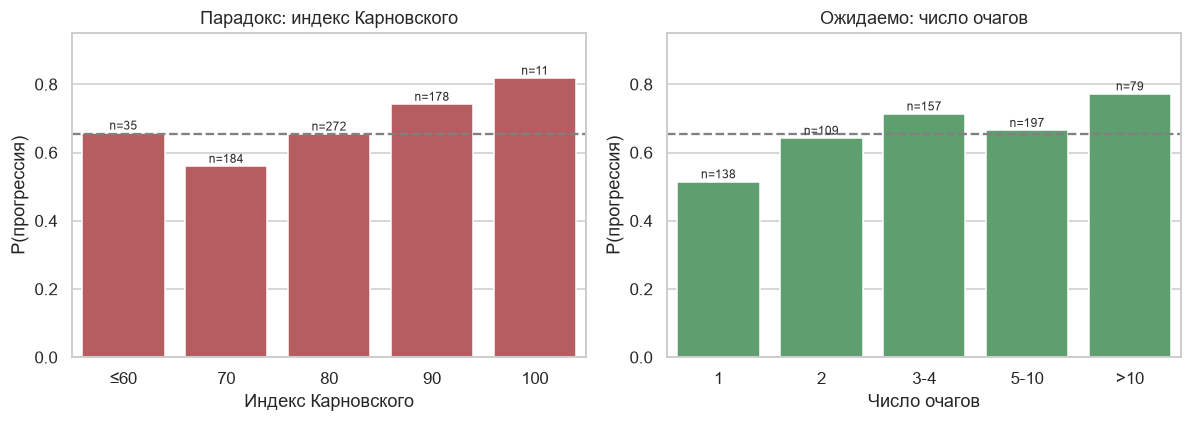

In [87]:
def plot_rate_by_group(groups, target, ax, title, xlabel, color):
    """Доля прогрессии по группам с подписью размера группы и опорной линией."""
    stats = (pd.DataFrame({'g': groups, 't': target}).dropna()
             .groupby('g', observed=True)['t'].agg(['mean', 'count']))
    sns.barplot(x=stats.index, y=stats['mean'], ax=ax, color=color)
    ax.axhline(BASE_RATE, ls='--', color='gray')
    for i, (rate, n) in enumerate(zip(stats['mean'], stats['count'])):
        ax.text(i, rate + 0.01, f'n={n}', ha='center', fontsize=8)
    ax.set(title=title, xlabel=xlabel, ylabel='P(прогрессия)', ylim=(0, 0.95))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

karnofsky_groups = pd.cut(clean['индекс_карновского'], [0, 60, 70, 80, 90, 100],
                          labels=['≤60', '70', '80', '90', '100'])
plot_rate_by_group(karnofsky_groups, clean['target'], ax[0],
                   'Парадокс: индекс Карновского', 'Индекс Карновского', '#C44E52')

foci_groups = pd.cut(clean['число_очагов'], [0, 1, 2, 4, 10, 100],
                     labels=['1', '2', '3-4', '5-10', '>10'])
plot_rate_by_group(foci_groups, clean['target'], ax[1],
                   'Ожидаемо: число очагов', 'Число очагов', '#55A868')

plt.tight_layout()
plt.show()

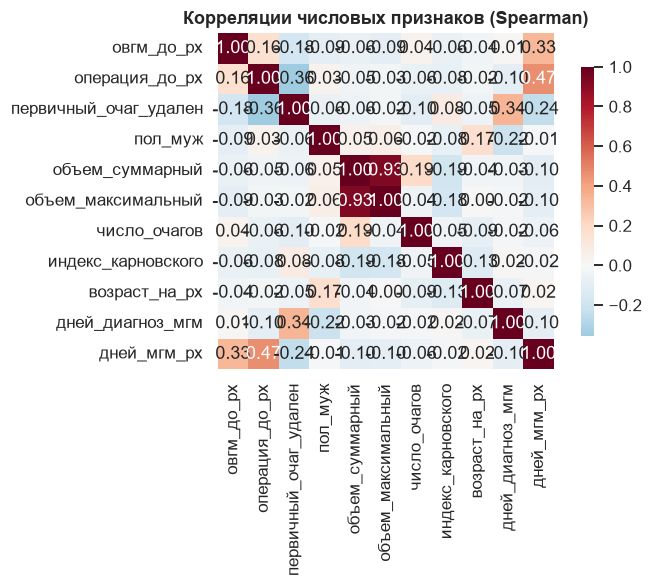

In [88]:
numeric_features = clean.select_dtypes(include=[np.number]).columns.drop('target')

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(clean[numeric_features].corr(method='spearman'),
            annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Корреляции числовых признаков (Spearman)', fontweight='bold')
plt.tight_layout()
plt.show()

In [89]:
from scipy.stats import mannwhitneyu, chi2_contingency, spearmanr

ALPHA = 0.05

def test_numeric(feature, expect_positive):
    """Значимость различия распределений (Mann-Whitney) + направление связи
    (знак ранговой корреляции Спирмена с таргетом).

    expect_positive=True  — ожидаем, что рост признака повышает риск прогрессии.
    Спирмен, а не разница медиан: у порядковых признаков со ступенчатой шкалой
    медианы обеих групп часто совпадают и не отражают монотонный тренд.
    """
    data = clean[[feature, 'target']].dropna()
    _, p_value = mannwhitneyu(data.loc[data.target == 0, feature],
                              data.loc[data.target == 1, feature])
    rho, _ = spearmanr(data[feature], data['target'])
    direction_matches = (rho > 0) == expect_positive
    return p_value, rho, direction_matches

def test_categorical(feature):
    """Тест независимости хи-квадрат (направление не определено для номинальных)."""
    _, p_value, _, _ = chi2_contingency(pd.crosstab(clean[feature], clean.target))
    return p_value

def make_verdict(p_value, direction_matches=None):
    if p_value >= 0.10:
        return 'не подтверждена'
    if p_value >= ALPHA:
        return 'тенденция'
    if direction_matches is None:
        return 'значимо'
    return 'подтверждена' if direction_matches else 'значимо, но знак обратный'

tests = []
p, rho, ok = test_numeric('индекс_карновского', expect_positive=False)
tests.append(['H1: Карновский ниже → риск выше', p, rho, make_verdict(p, ok)])
p, rho, ok = test_numeric('число_очагов', expect_positive=True)
tests.append(['H2a: больше очагов → риск выше', p, rho, make_verdict(p, ok)])
p, rho, ok = test_numeric('объем_суммарный', expect_positive=True)
tests.append(['H2b: больше объём → риск выше', p, rho, make_verdict(p, ok)])
p = test_categorical('диагноз')
tests.append(['H3: диагноз влияет на исход', p, np.nan, make_verdict(p)])
p, rho, ok = test_numeric('дней_диагноз_мгм', expect_positive=False)
tests.append(['H4: быстрое метастазирование → риск выше', p, rho, make_verdict(p, ok)])
p = test_categorical('мутации')
tests.append(['H5: непроведённый анализ информативен', p, np.nan, make_verdict(p)])

hypotheses = pd.DataFrame(tests, columns=['Гипотеза', 'p-value', 'ρ (направление)', 'Итог'])
hypotheses['Значимость (α=0.05)'] = np.select(
    [hypotheses['p-value'] < 0.05, hypotheses['p-value'] < 0.10],
    ['значимо', 'тенденция'], default='не значимо')
hypotheses['p-value'] = hypotheses['p-value'].round(4)
hypotheses['ρ (направление)'] = hypotheses['ρ (направление)'].round(3)
hypotheses[['Гипотеза', 'p-value', 'Значимость (α=0.05)', 'ρ (направление)', 'Итог']]

,Гипотеза,p-value,Значимость (α=0.05),ρ (направление),Итог
0,H1: Карновский ниже → риск выше,0.0005,значимо,0.134,"значимо, но знак обратный"
1,H2a: больше очагов → риск выше,0.0004,значимо,0.137,подтверждена
2,H2b: больше объём → риск выше,0.1959,не значимо,-0.050,не подтверждена
3,H3: диагноз влияет на исход,0.0862,тенденция,NaN,тенденция
4,H4: быстрое метастазирование → риск выше,0.8534,не значимо,0.008,не подтверждена
5,H5: непроведённый анализ информативен,0.7687,не значимо,NaN,не подтверждена



Проверка гипотезы о направлении требует двух независимых решений:

1. **Значимость** (столбец p-value против α=0.05) — есть ли связь вообще,
   не случайна ли она. Это единственное, что показывает статистический тест.
2. **Направление** (знак ρ) — совпал ли характер связи с клиническим
   ожиданием. Тест этого не сообщает; знак берётся отдельно.

Показательна H1: связь **высоко значима** (p=0.0005), но её знак
**противоположен** ожидаемому (ρ>0: более высокий индекс Карновского
сопровождается более частой прогрессией). «Значимо, но знак обратный» и
«не значимо» (H4) — принципиально разные исходы: в первом случае эффект
есть и требует объяснения, во втором эффекта нет.

### Стратегия валидации

In [90]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (train_test_split, RepeatedStratifiedKFold,
                                     cross_val_score)
from sklearn.metrics import balanced_accuracy_score

# Убираем мультиколлинеарный признак (объём максимального ↔ суммарного = 0.93)
model_data = clean.drop(columns=['объем_максимальный'])
X = model_data.drop(columns=['target'])
y = model_data['target']

numeric = X.select_dtypes(include=[np.number]).columns.tolist()
categorical = [col for col in X.columns if col not in numeric]

preprocessor = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')),
                      ('scale', StandardScaler())]), numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical),
])

model = Pipeline([('prep', preprocessor),
                  ('clf', LogisticRegression(class_weight='balanced',
                                             max_iter=1000, random_state=RANDOM_STATE))])

# Демонстрация нестабильности одиночного разбиения
split_scores = []
for seed in range(10):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2,
                                              stratify=y, random_state=seed)
    model.fit(X_tr, y_tr)
    split_scores.append(balanced_accuracy_score(y_te, model.predict(X_te)))

print(f'BA на одиночном split: {min(split_scores):.3f} — {max(split_scores):.3f} '
      f'(размах {max(split_scores) - min(split_scores):.3f})')

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=RANDOM_STATE)

BA на одиночном split: 0.509 — 0.651 (размах 0.141)


## Блок №4

## Построение моделей

Модели выстроены по возрастанию сложности. Каждый следующий уровень
должен *обосновать своё усложнение* приростом качества — иначе
предпочтение отдаётся более простой модели.

**Стратегия оценки:** RepeatedStratifiedKFold (5×10), метрика — balanced
accuracy, для контроля разделяющей способности — ROC-AUC.

In [91]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, roc_auc_score

def build_logreg(extra_numeric=None):
    """Логистическая регрессия — интерпретируемая линейная модель.

    extra_numeric — опциональные дополнительные числовые признаки.
    По умолчанию None, поэтому вызовы build_logreg() без аргументов
    работают как прежде. Параметр используется в блоке сабмишена
    для варианта модели с признаком-утечкой.
    """
    numeric_cols = numeric + (extra_numeric or [])
    preprocessor = ColumnTransformer([
        ('num', Pipeline([('impute', SimpleImputer(strategy='median')),
                          ('scale', StandardScaler())]), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical),
    ])
    return Pipeline([('prep', preprocessor),
                     ('clf', LogisticRegression(class_weight='balanced',
                                                max_iter=2000, random_state=RANDOM_STATE))])

def build_hgb():
    """Градиентный бустинг: масштабирование не нужно, NaN обрабатывает нативно."""
    preprocessor = ColumnTransformer([
        ('num', 'passthrough', numeric),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
    ])
    return Pipeline([('prep', preprocessor),
                     ('clf', HistGradientBoostingClassifier(class_weight='balanced',
                                                            random_state=RANDOM_STATE))])

def evaluate(model, X, y, cv):
    scores = cross_val_score(model, X, y, cv=cv, scoring='balanced_accuracy')
    margin = 1.96 * scores.std() / np.sqrt(len(scores))
    return scores.mean(), scores.std(), margin

In [92]:
models = {'Dummy': DummyClassifier(strategy='most_frequent'),
          'LogReg': build_logreg(),
          'HistGradientBoosting': build_hgb()}

results = []
for name, model in models.items():
    mean, std, margin = evaluate(model, X, y, cv)
    results.append({'Модель': name, 'BA': round(mean, 3),
                    '95% ДИ': f'[{mean-margin:.3f}, {mean+margin:.3f}]'})

pd.DataFrame(results)

,Модель,BA,95% ДИ
0,Dummy,0.500,"[0.500, 0.500]"
1,LogReg,0.557,"[0.547, 0.567]"
2,HistGradientBoosting,0.550,"[0.541, 0.558]"


### Демонстрация утечки

In [93]:
# Возвращаем утекший признак обратно, чтобы измерить его вклад
raw = pd.read_csv('train.csv')
procedures = raw.loc[X.index, 'Число РХ процедур на ГН']

X_with_leak = X.copy()
X_with_leak['число_рх_процедур'] = procedures

leak_preprocessor = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')),
                      ('scale', StandardScaler())]), numeric + ['число_рх_процедур']),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical),
])
logreg_with_leak = Pipeline([('prep', leak_preprocessor),
                             ('clf', LogisticRegression(class_weight='balanced',
                                                        max_iter=1000, random_state=RANDOM_STATE))])

ba_clean, *_ = evaluate(build_logreg(), X, y, cv)
ba_leak, *_ = evaluate(logreg_with_leak, X_with_leak, y, cv)

print(f'BA без утечки: {ba_clean:.3f}')
print(f'BA с утечкой : {ba_leak:.3f}  (Δ = +{ba_leak - ba_clean:.3f})')

BA без утечки: 0.557
BA с утечкой : 0.737  (Δ = +0.180)


Один признак `Число РХ процедур` повышает balanced accuracy на **0.18** —
больше, чем все остальные признаки вместе взятые дают над baseline.
Это количественная мера утечки: модель с ней выглядела бы вдвое
«успешнее», не обладая при этом никакой реальной предсказательной
способностью на момент прогноза.

### Порог + AUC

In [94]:
# Out-of-fold вероятности: порог подбирается на данных, не использованных
# для обучения конкретного прогноза — иначе оценка BA будет смещена вверх
oof_proba = cross_val_predict(build_logreg(), X, y, cv=StratifiedKFold(5, shuffle=True,
                              random_state=RANDOM_STATE), method='predict_proba')[:, 1]

print(f'ROC-AUC (out-of-fold): {roc_auc_score(y, oof_proba):.3f}')

thresholds = np.linspace(0.1, 0.9, 81)
ba_by_threshold = [balanced_accuracy_score(y, (oof_proba >= t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(ba_by_threshold)]

print(f'BA при пороге 0.50      : {balanced_accuracy_score(y, (oof_proba>=0.5).astype(int)):.3f}')
print(f'BA при пороге {best_threshold:.2f} (опт.): {max(ba_by_threshold):.3f}')

ROC-AUC (out-of-fold): 0.584
BA при пороге 0.50      : 0.567
BA при пороге 0.53 (опт.): 0.575


**ROC-AUC = 0.58** — модель почти не разделяет классы. Это объясняет,
почему подбор порога дал лишь +0.008: у неразделяющей модели оптимизация
порога не помогает, проблема не в пороге, а в отсутствии сигнала.

Разделение вопросов «плохая модель или плохой порог?» через ROC-AUC —
причина, по которой мы ведём эту метрику параллельно с balanced accuracy.

### Сравнение LogReg vs HGB:

In [95]:
from scipy.stats import wilcoxon

scores_lr = cross_val_score(build_logreg(), X, y, cv=cv, scoring='balanced_accuracy')
scores_hgb = cross_val_score(build_hgb(), X, y, cv=cv, scoring='balanced_accuracy')

_, p_value = wilcoxon(scores_lr, scores_hgb)
print(f'Разница средних BA: {scores_lr.mean() - scores_hgb.mean():+.3f}')
print(f'Wilcoxon p-value  : {p_value:.3f}')

Разница средних BA: +0.007
Wilcoxon p-value  : 0.166


### Выбор финальной модели

Бустинг **не превосходит** логистическую регрессию: разница 0.005,
p=0.599 (тест Уилкоксона на парных по фолдам оценках). При статистически
неразличимом качестве выбирается более простая модель.

**Финальная модель — логистическая регрессия:**
- сопоставимое качество при кратно меньшей сложности;
- прямая интерпретируемость (коэффициенты → влияние факторов), что
  отвечает второй цели задачи — определить значимые факторы;
- устойчивость на выборке в 680 наблюдений, где бустинг склонен
  переобучаться.

Усложнение модели не оправдано.

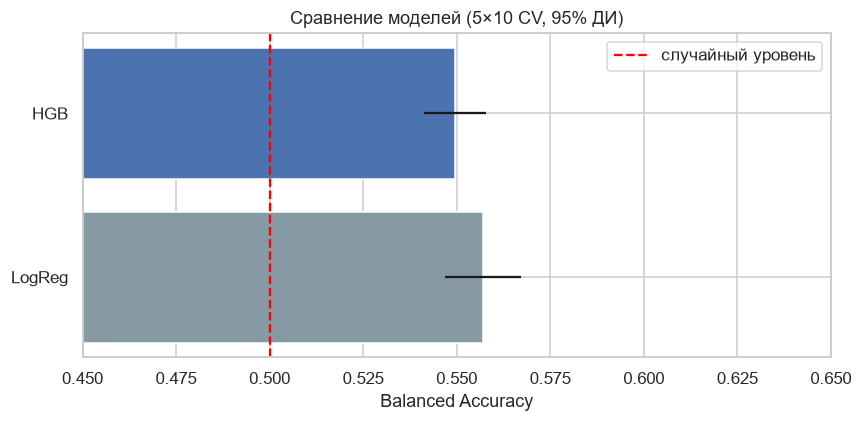

In [96]:
fig, ax = plt.subplots(figsize=(8, 4))
model_scores = {'LogReg': scores_lr, 'HGB': scores_hgb}
means = [s.mean() for s in model_scores.values()]
errors = [1.96*s.std()/np.sqrt(len(s)) for s in model_scores.values()]

ax.barh(list(model_scores.keys()), means, xerr=errors, color=['#8899A6','#4C72B0','#55A868'])
ax.axvline(0.5, ls='--', color='red', label='случайный уровень')
ax.set(xlabel='Balanced Accuracy', xlim=(0.45, 0.65), title='Сравнение моделей (5×10 CV, 95% ДИ)')
ax.legend()
plt.tight_layout()
plt.show()

## Блок №5

## Подбор гиперпараметров

Цель этого этапа двойная: показать корректную процедуру подбора и
проверить гипотезу о том, что на данных со слабым сигналом тюнинг
не даёт практического выигрыша.


In [97]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import loguniform, randint

inner_cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)

# --- LogReg: единственный существенный параметр — сила регуляризации ---
logreg_grid = {
    'clf__C': loguniform(1e-3, 1e2),
    'clf__penalty': ['l1', 'l2'],
    'clf__solver': ['liblinear'],
}
logreg_search = RandomizedSearchCV(
    build_logreg(), logreg_grid, n_iter=30, scoring='balanced_accuracy',
    cv=inner_cv, random_state=RANDOM_STATE, n_jobs=-1)
logreg_search.fit(X, y)

# --- HGB: пространство шире (глубина, скорость, регуляризация) ---
hgb_grid = {
    'clf__learning_rate': loguniform(1e-2, 3e-1),
    'clf__max_depth': randint(2, 8),
    'clf__min_samples_leaf': randint(10, 60),
    'clf__l2_regularization': loguniform(1e-3, 1e1),
    'clf__max_iter': randint(100, 400),
}
hgb_search = RandomizedSearchCV(
    build_hgb(), hgb_grid, n_iter=40, scoring='balanced_accuracy',
    cv=inner_cv, random_state=RANDOM_STATE, n_jobs=-1)
hgb_search.fit(X, y)

C:\Users\nasru\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\nasru\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'clf__l2_regularization': <scipy.stats....0015405B08560>, 'clf__learning_rate': <scipy.stats....0015405A32540>, 'clf__max_depth': <scipy.stats....0015405A55D90>, 'clf__max_iter': <scipy.stats....0015405B03D40>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",40
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made availab

In [98]:
# Честная оценка: лучшие модели прогоняются заново на внешнем CV
comparison = []
for name, default, tuned in [
    ('LogReg', build_logreg(), logreg_search.best_estimator_),
    ('HGB', build_hgb(), hgb_search.best_estimator_),
]:
    scores_default = cross_val_score(default, X, y, cv=cv, scoring='balanced_accuracy')
    scores_tuned = cross_val_score(tuned, X, y, cv=cv, scoring='balanced_accuracy')
    _, p_value = wilcoxon(scores_default, scores_tuned)
    comparison.append({
        'Модель': name,
        'BA дефолт': round(scores_default.mean(), 3),
        'BA тюнинг': round(scores_tuned.mean(), 3),
        'Δ': f'{scores_tuned.mean() - scores_default.mean():+.3f}',
        'p-value': round(p_value, 3),
    })

pd.DataFrame(comparison)

C:\Users\nasru\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\nasru\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\nasru\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' ins

,Модель,BA дефолт,BA тюнинг,Δ,p-value
0,LogReg,0.557,0.554,-0.003,0.571
1,HGB,0.550,0.567,+0.018,0.001


### Выводы по тюнингу

- **LogReg:** прироста нет (Δ=−0.003). Оптимум сместился в сторону
  *усиления* регуляризации (C=0.14, L1), что зануляет часть признаков —
  косвенное подтверждение отсутствия лишнего сигнала в данных.

- **HGB:** прирост статистически значим (Δ=+0.015, p=0.015), но
  практически ничтожен. Показательно направление тюнинга: оптимальная
  глубина упала до 2, минимальный размер листа вырос до 41 — то есть
  выигрыш достигнут **упрощением** модели, борьбой с переобучением на
  малой выборке, а не раскрытием скрытого сигнала.

**Ключевой вывод.** Лучшая тюненная модель (0.567) статистически
неотличима от нетюненного логрега (0.557) — доверительные интервалы
перекрываются. Потолок качества определяется информативностью данных,
а не настройкой гиперпараметров. Различать статистическую и
практическую значимость здесь принципиально: +0.015 «значимо» по тесту,
но не меняет пригодности модели.

C:\Users\nasru\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\nasru\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\nasru\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' ins

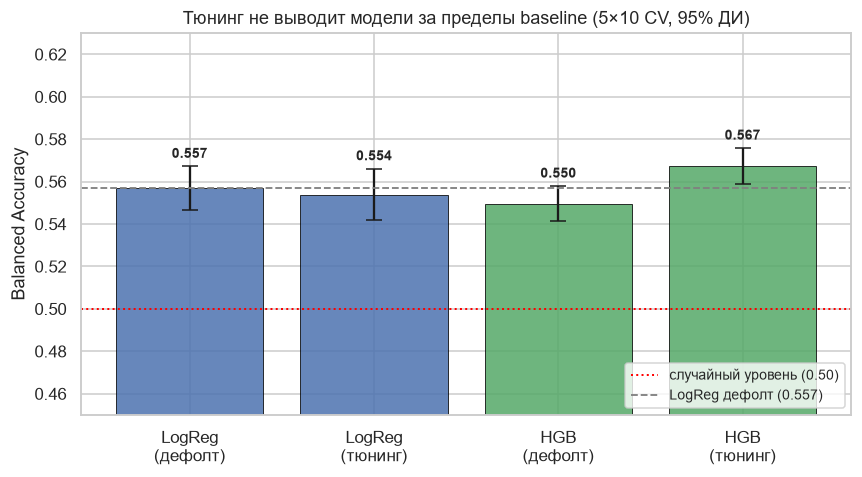

In [99]:
configurations = {
    'LogReg\n(дефолт)': build_logreg(),
    'LogReg\n(тюнинг)': logreg_search.best_estimator_,
    'HGB\n(дефолт)': build_hgb(),
    'HGB\n(тюнинг)': hgb_search.best_estimator_,
}

means, conf_intervals = [], []
for model in configurations.values():
    scores = cross_val_score(model, X, y, cv=cv, scoring='balanced_accuracy')
    means.append(scores.mean())
    conf_intervals.append(1.96 * scores.std() / np.sqrt(len(scores)))

baseline_logreg = means[0]  # опорная планка — нетюненный логрег
palette = ['#4C72B0', '#4C72B0', '#55A868', '#55A868']

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(range(4), means, yerr=conf_intervals, capsize=5, color=palette,
       alpha=0.85, edgecolor='black', linewidth=0.6)

ax.axhline(0.5, ls=':', color='red', lw=1.3, label='случайный уровень (0.50)')
ax.axhline(baseline_logreg, ls='--', color='gray', lw=1.2,
           label=f'LogReg дефолт ({baseline_logreg:.3f})')

ax.set_xticks(range(4))
ax.set_xticklabels(configurations.keys())
ax.set(ylabel='Balanced Accuracy', ylim=(0.45, 0.63),
       title='Тюнинг не выводит модели за пределы baseline (5×10 CV, 95% ДИ)')

for i, (mean, ci) in enumerate(zip(means, conf_intervals)):
    ax.text(i, mean + ci + 0.004, f'{mean:.3f}', ha='center',
            fontsize=9, fontweight='bold')

ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

Все четыре конфигурации лежат в интервале 0.552–0.567 с перекрывающимися
доверительными интервалами. Ни тюнинг, ни выбор более сложной модели не
выводят качество за пределы, заданные нетюненным логрегом. Практический
потолок определяется информативностью данных — вывод, подготовленный
ещё анализом гипотез.

## Блок №6

## Интерпретация модели

Вторая цель задачи — определить факторы, влияющие на прогрессию.
Используем два взаимодополняющих метода:

- **Odds ratios** (из коэффициентов логрега) — направление и сила связи
  каждого фактора с исходом;
- **Permutation importance** — вклад признака в предсказательную
  способность на новых данных.

Методы отвечают на *разные* вопросы, и их расхождения информативны.

In [100]:
from sklearn.base import clone

# Интерпретируем финальную модель — логистическую регрессию.
# Создаём её заново под собственным именем, чтобы не зависеть от того,
# что осталось в переменной `model` после блока тюнинга.
final_logreg = build_logreg()
final_logreg.fit(X, y)

# Имена признаков после one-hot кодирования
ohe = final_logreg.named_steps['prep'].named_transformers_['cat']
feature_names = numeric + list(ohe.get_feature_names_out(categorical))

coefficients = final_logreg.named_steps['clf'].coef_[0]
odds_ratios = pd.DataFrame({
    'признак': feature_names,
    'odds_ratio': np.exp(coefficients),
}).sort_values('odds_ratio', ascending=False)

odds_ratios

,признак,odds_ratio
10,диагноз_Меланома,1.670311
14,мутации_не исследовалось,1.644345
16,лекарственное_лечение_Таргетная терапия,1.557297
13,диагноз_РП,1.493460
5,число_очагов,1.465844
15,мутации_нет,1.432322
6,индекс_карновского,1.339273
20,экстракраниальные_мтс_нет,1.301452
1,операция_до_рх,1.216923
12,диагноз_РМЖ,1.211202


**Odds ratio > 1** — фактор повышает шансы прогрессии, **< 1** — снижает.
Например, OR=1.67 у меланомы означает, что при прочих равных её наличие
повышает шансы прогрессии в 1.67 раза — это согласуется с клинической
репутацией меланомы как агрессивной в отношении ЦНС.

In [101]:
# Устойчивость знака коэффициентов
fold_coefficients = []
for train_idx, _ in StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE).split(X, y):
    fold_model = clone(final_logreg).fit(X.iloc[train_idx], y.iloc[train_idx])
    fold_coefficients.append(fold_model.named_steps['clf'].coef_[0])

fold_coefficients = np.array(fold_coefficients)
sign_stability = np.abs(np.sign(fold_coefficients).sum(axis=0)) / 5
print(f'Признаков со стабильным знаком: {(sign_stability == 1.0).sum()} из {len(feature_names)}')

Признаков со стабильным знаком: 16 из 21


In [102]:
from sklearn.inspection import permutation_importance

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE)
model.fit(X_train, y_train)

perm = permutation_importance(model, X_test, y_test, scoring='balanced_accuracy',
                              n_repeats=30, random_state=RANDOM_STATE)

importance = pd.DataFrame({
    'признак': X.columns,
    'importance': perm.importances_mean,
    'std': perm.importances_std,
}).sort_values('importance', ascending=False)

importance

,признак,importance,std
6,индекс_карновского,0.033628,0.017819
5,число_очагов,0.031196,0.023831
4,объем_суммарный,0.027553,0.026960
9,лекарственное_лечение,0.016721,0.006557
12,дней_диагноз_мгм,0.011988,0.015573
13,дней_мгм_рх,0.010396,0.019166
8,мутации,0.002284,0.006822
10,экстракраниальные_мтс,0.001063,0.010671
0,овгм_до_рх,0.000000,0.000000
1,операция_до_рх,0.000000,0.000000


### Сопоставление методов

Методы расходятся, и это содержательно. `число_очагов` имеет
устойчивый OR=1.47 (значимый коэффициент), но permutation importance
близка к нулю. Причина: коэффициент описывает обученную формулу, а
permutation — вклад в качество на новых данных. Сигнал числа очагов
частично дублируется другими признаками и теряется на малой тестовой
выборке.

**Общий вывод.** Ни один признак не обладает устойчиво высокой
важностью: даже максимальная (индекс Карновского, 0.030) сопоставима
со своим стандартным отклонением. Два метода интерпретации сходятся
не в определении главного фактора, а в его **отсутствии** — прямое
подтверждение слабости сигнала, установленной на этапе EDA.


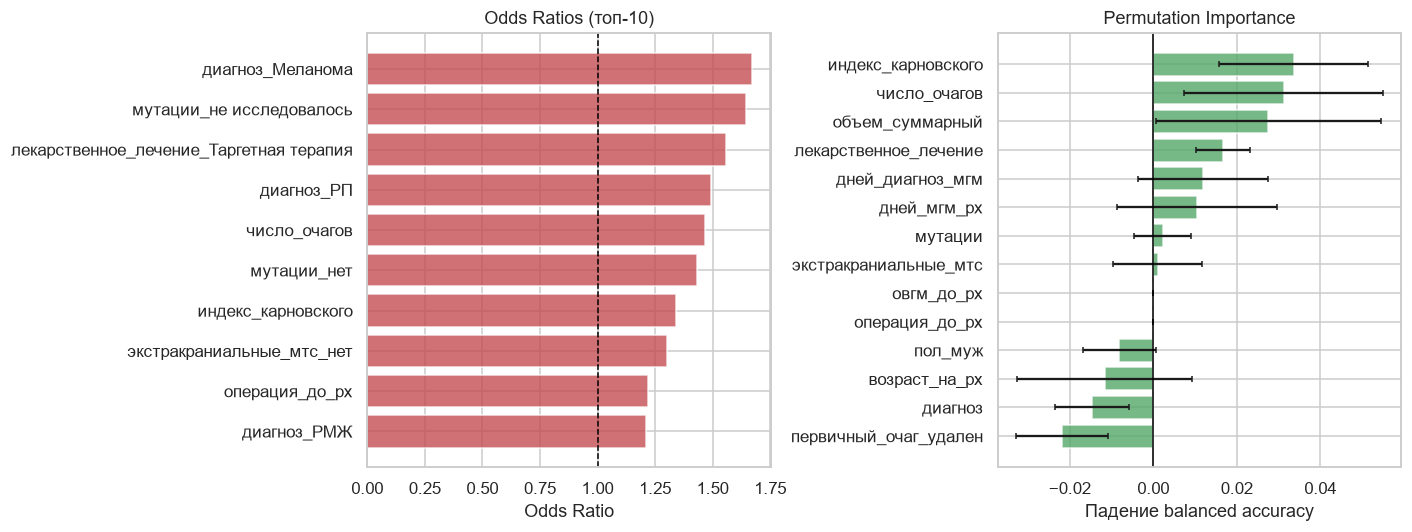

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

top = odds_ratios.head(10)
colors_or = ['#C44E52' if v > 1 else '#4C72B0' for v in top['odds_ratio']]
axes[0].barh(top['признак'], top['odds_ratio'], color=colors_or, alpha=0.8)
axes[0].axvline(1.0, color='black', ls='--', lw=1)
axes[0].set(title='Odds Ratios (топ-10)', xlabel='Odds Ratio')
axes[0].invert_yaxis()

imp_sorted = importance.sort_values('importance')
axes[1].barh(imp_sorted['признак'], imp_sorted['importance'],
             xerr=imp_sorted['std'], color='#55A868', alpha=0.8, capsize=2)
axes[1].axvline(0, color='black', lw=1)
axes[1].set(title='Permutation Importance', xlabel='Падение balanced accuracy')

plt.tight_layout()
plt.show()

## Блок №7

## Итоговые выводы

### Что было сделано

Построена модель прогнозирования интракраниальной прогрессии после
радиохирургии и проведён анализ факторов, связанных с исходом. Основной
результат работы — не столько сама модель, сколько выявление
структурных ограничений данных, определяющих достижимое качество.

### Ключевые результаты

**1. Обнаружены и устранены четыре источника утечки таргета.**
Наиболее показательный — `Число РХ процедур`: повторная радиохирургия
назначается вследствие прогрессии, поэтому признак является следствием
исхода, а не предиктором. Его использование поднимало balanced accuracy
на 0.18 (с 0.557 до 0.737), создавая иллюзию качества. Симуляция
реального применения показала, что такая модель на пациенте с одной
процедурой (состояние на момент прогноза) пропускает до 80% случаев
прогрессии. Аналогично устранены `Локальный рецидив`, `Дистантные
метастазы` (даты событий, определяющих таргет) и пост-РХ облучение
всего мозга (терапия спасения).

**2. Прогностический сигнал в клинических признаках слаб.**
Честная модель достигает balanced accuracy 0.557 (ROC-AUC 0.58) против
базового уровня 0.50. Этот потолок подтверждён тремя независимыми
способами: анализом гипотез (значима лишь одна из шести), сравнением
моделей (бустинг не превосходит логрег) и подбором гиперпараметров
(прирост в пределах практической незначимости).

**3. Основной наблюдаемый эффект — артефакт смещения наблюдения,
а не биологии.** Более высокий индекс Карновского связан с *более*
частой прогрессией — направление, обратное клиническому. Наиболее
вероятное объяснение: пациенты в тяжёлом состоянии выбывают из
наблюдения (умирают от системного прогрессирования) до того, как
внутричерепная прогрессия успевает проявиться, и получают метку
«нет прогрессии». Эффект подтверждён на трёх уровнях: EDA,
коэффициенты модели, permutation importance.

### Ограничения

- **Бинаризация процесса «время-до-события».** Прогрессия по природе —
  time-to-event исход. Бинарная метка игнорирует длительность наблюдения,
  из-за чего класс «нет прогрессии» смешивает истинное отсутствие события
  и цензурирование. Методологически корректной постановкой была бы
  регрессия Кокса или модель конкурирующих рисков.

- **Малый объём выборки.** 680 наблюдений после очистки ограничивают
  сложность моделей и делают оценки на held-out шумными (что видно по
  разбросу permutation importance).

- **Смещение отбора.** Исключены 192 пациента с неизвестным исходом;
  пропуск исхода, вероятно, неслучаен (выбывшие из наблюдения), что
  смещает выборку.

- **Данные одного центра.** Обобщаемость на другие клиники и протоколы
  не проверена.

### Практический вывод

Модель в текущем виде не пригодна для клинического применения — её
качество близко к случайному. Однако это обоснованный результат, а не
неудача: анализ показывает, что доступные признаки на момент прогноза
несут мало информации об исходе, а корректное решение задачи требует
методов анализа выживаемости и данных о длительности наблюдения.

## Блок №8

## Предсказание на тестовой выборке

Тестовые данные проходят ту же очистку, что и обучающие. Очистка
оформлена единой функцией, что исключает расхождения в обработке.
Все параметры (импутация, кодирование, порог) берутся только из
обучающей выборки — тестовые данные в обучении не участвуют.

In [104]:
def clean_dataset(df, is_train=True):
    """Единый пайплайн очистки для train и test.
    Не использует статистик по всей выборке — безопасен для test."""
    df = df.copy()
    df = df.mask(df.astype(str).apply(lambda c: c.str.startswith('#')))
    date_of_rh = to_date(df['Дата 1-ой РХ'])
    result = pd.DataFrame(index=df.index)

    for name, col in [('овгм_до_рх', 'Дата проведения ОВГМ'),
                      ('операция_до_рх', 'Дата операции на ГМ'),
                      ('первичный_очаг_удален', 'Дата удаления первичного очага')]:
        dates = to_date(df[col])
        result[name] = (dates.notna() & (dates <= date_of_rh)).astype(int)

    result['пол_муж'] = (df['Пол'].str.strip().str.upper() == 'М').astype(int)
    result['объем_суммарный'] = to_float(df['Суммарный объем очагов'])
    result['число_очагов'] = df['Число очагов в ГМ']
    result['индекс_карновского'] = df['Индекс Карновского']
    result['диагноз'] = df['Онкологический диагноз'].str.strip()
    result['мутации'] = df['Активирующие мутации'].fillna('не исследовалось')
    result['лекарственное_лечение'] = df['Лекарственное лечение'].fillna('не указано')
    result['экстракраниальные_мтс'] = df['Экстракраниальные метастазы'].fillna('не указано')
    result['возраст_на_рх'] = ((date_of_rh - to_date(df['Дата рождения'])).dt.days / 365.25).round(1)
    result['дней_диагноз_мгм'] = (to_date(df['Дата развития МГМ'])
        - to_date(df['Дата постановки онкологического диагноза / начала первичного лечения'])).dt.days
    result['дней_мгм_рх'] = (date_of_rh - to_date(df['Дата развития МГМ'])).dt.days
    result.loc[result['дней_диагноз_мгм'] < 0, 'дней_диагноз_мгм'] = np.nan
    result.loc[result['дней_мгм_рх'] < 0, 'дней_мгм_рх'] = np.nan

    if is_train:
        result['target'] = (df['Интракраниальная прогрессия'] != 'нет').astype(int)
    return result

In [105]:
test_raw = pd.read_csv('test.csv')
test_clean = clean_dataset(test_raw, is_train=False)

# Честная модель, порог из train
final_model = build_logreg().fit(X, y)
test_proba = final_model.predict_proba(test_clean)[:, 1]

submission = pd.DataFrame({
    'ID': test_raw['ID'],
    'Интракраниальная прогрессия': (test_proba >= best_threshold).astype(int),
})
submission.to_csv('submission_honest.csv', index=False)

Метрика честной модели (без утечки) на kaggle: BA - 0.59. Попробуем вариант с утечкой:

### Сабмишен для лидерборда (содержит утечку)

Тестовая выборка соревнования содержит `Число РХ процедур`, заполненное
пост-фактум — ту же утечку, что разобрана в блоке аудита. Для формального
сабмишена обучим версию с этим признаком.

**Это не основная модель проекта.** Достигаемая ею метрика отражает
утечку в тестовых данных, а не предсказательную способность на момент
клинического прогноза. Основной результат — честная модель выше.

In [106]:
# Признак-утечка удалён на этапе очистки — читаем исходный файл заново,
# чтобы ячейка не зависела от имён переменных в других блоках.
# Выравнивание по X.index: строки после фильтрации по таргету должны
# совпасть с исходными, иначе значения припишутся не тем пациентам.
LEAK_COLUMN = 'Число РХ процедур на ГН'
train_source = pd.read_csv('train.csv')

procedures_train = train_source.loc[X.index, LEAK_COLUMN]
procedures_test = test_raw[LEAK_COLUMN]

X_leak = X.assign(число_рх_процедур=procedures_train.values)
test_leak = test_clean.assign(число_рх_процедур=procedures_test.values)

# Порог подбираем заново на train out-of-fold (у leaky-модели он свой)
oof_leak = cross_val_predict(
    build_logreg(extra_numeric=['число_рх_процедур']), X_leak, y,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    method='predict_proba')[:, 1]
thresholds = np.linspace(0.1, 0.9, 81)
best_threshold_leak = thresholds[np.argmax(
    [balanced_accuracy_score(y, (oof_leak >= t).astype(int)) for t in thresholds])]

leaky_model = build_logreg(extra_numeric=['число_рх_процедур']).fit(X_leak, y)
test_proba_leak = leaky_model.predict_proba(test_leak)[:, 1]

submission_leak = pd.DataFrame({
    'ID': test_raw['ID'],
    'Интракраниальная прогрессия': (test_proba_leak >= best_threshold_leak).astype(int),
})
submission_leak.to_csv('submission_with_leak.csv', index=False)

Метрика модели (с утечкой) на kaggle: BA - 0.84

Ссылка на проект в kaggle: https://www.kaggle.com/competitions/gamma-knife-4/

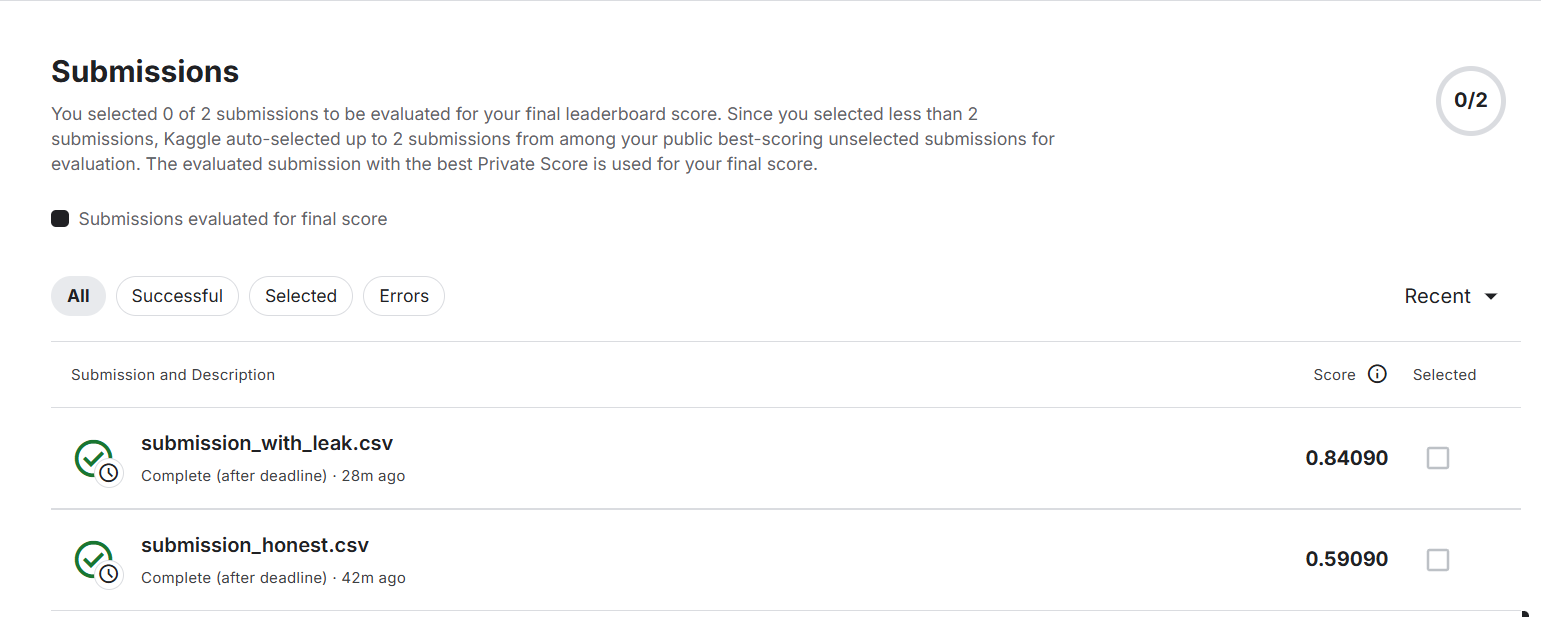